# 12. Diffusion Model


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)


### Diffusion Schedule
This is the noise added at each step, and its cumalative product.

Timestep t = 5
beta_t      = 0.011156  (noise variance added at step t)
alpha_t     = 0.988844  (signal retention at step t)
alpha_bar_t = 0.966663  (cumulative signal retention up to t)


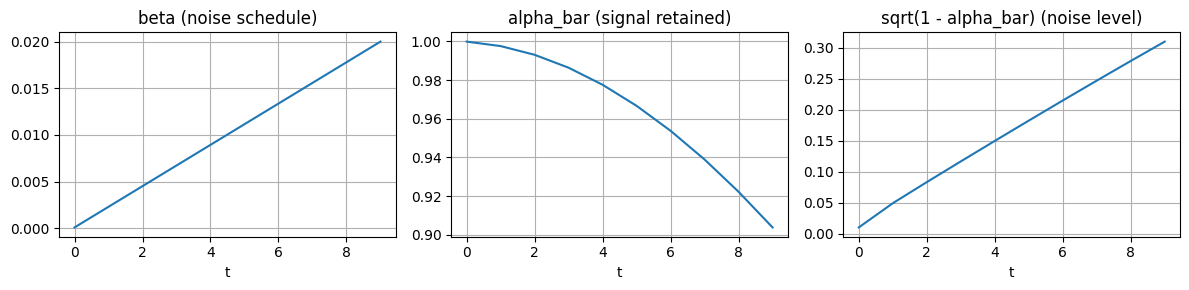

In [2]:
T = 10
beta = np.linspace(0.0001, 0.02, T)
alpha = 1 - beta
alpha_bar = np.cumprod(alpha)

t = 5
beta_t = beta[t]
alpha_t = alpha[t]
alpha_bar_t = alpha_bar[t]

print(f"Timestep t = {t}")
print(f"beta_t      = {beta_t:.6f}  (noise variance added at step t)")
print(f"alpha_t     = {alpha_t:.6f}  (signal retention at step t)")
print(f"alpha_bar_t = {alpha_bar_t:.6f}  (cumulative signal retention up to t)")

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].plot(beta); axes[0].set_title("beta (noise schedule)"); axes[0].set_xlabel("t")
axes[1].plot(alpha_bar); axes[1].set_title("alpha_bar (signal retained)"); axes[1].set_xlabel("t")
axes[2].plot(np.sqrt(1 - alpha_bar)); axes[2].set_title("sqrt(1 - alpha_bar) (noise level)"); axes[2].set_xlabel("t")
for ax in axes: ax.grid(True)
plt.tight_layout()
plt.show()

I added the reverse step, which is stochastic, by adding a small amount of Gaussian noise z to avoid the output collapsing to the mean (I used a randomizer), and matched the shape of x_t so the noise has the same dimensionality.


In [ ]:
x_t = np.array([1.5, -0.3])
eps_theta = np.array([0.2, -0.1]) 

z = np.random.randn(*x_t.shape)

print("x_t (noisy input)           =", x_t)
print("eps_theta (predicted noise)  =", eps_theta)
print("z (sampled stochastic noise) =", z)
print("z shape matches x_t shape:  ", z.shape == x_t.shape)

x_t (noisy input)           = [ 1.5 -0.3]
eps_theta (predicted noise)  = [ 0.2 -0.1]
z (sampled stochastic noise) = [1.76405235 0.40015721]
z shape matches x_t shape:   True


Then, after the reverse step formula, I added the mu calcuations to undo the signal scaling from the forward step, remove the noise the network estimates was added, and reinjected a small amount of noise to stay stochastic. 

In [ ]:
sigma_t = np.sqrt(beta_t)

mu = (1 / np.sqrt(alpha_t)) * (x_t - (beta_t / np.sqrt(1 - alpha_bar_t)) * eps_theta)
x_prev = mu + sigma_t * z

print(f"sigma_t (std dev of noise)   = {sigma_t:.6f}")
print(f"mu (denoised mean)           = {mu}")
print(f"x_prev (reverse step output) = {x_prev}")
print()
print("Summary:")
print(f"  x_t      = {x_t}")
print(f"  pred eps = {eps_theta}")
print(f"  noise z  = {z}")
print(f"  x_{{t-1}} = {x_prev}")

sigma_t (std dev of noise)   = 0.105620
mu (denoised mean)           = [ 1.49614896 -0.29554328]
x_prev (reverse step output) = [ 1.68246793 -0.25327873]

Summary:
  x_t      = [ 1.5 -0.3]
  pred eps = [ 0.2 -0.1]
  noise z  = [1.76405235 0.40015721]
  x_{t-1} = [ 1.68246793 -0.25327873]


Then I added the forward step, which is the opposite/flip of a clean image, producing the nosier 'x_t' useing reparameterizaton, and added gaussian noise.


In [ ]:
np.random.seed(0)

T = 10
beta = np.linspace(0.0001, 0.02, T)
alpha = 1 - beta

t = 3
beta_t = beta[t]
alpha_t = alpha[t]

x_prev = np.array([1.0, -0.5])


eps = np.random.randn(*x_prev.shape)
x_t = np.sqrt(alpha_t) * x_prev + np.sqrt(beta_t) * eps

print(f"Timestep t = {t}")
print(f"alpha_t = {alpha_t:.6f},  beta_t = {beta_t:.6f}")
print()
print(f"x_(t-1) (clean input)  = {x_prev}")
print(f"eps (sampled noise)    = {eps}")
print(f"x_t (noisy output)     = {x_t}")
print()
print(f"Signal component: sqrt(alpha_t) * x_prev = {np.sqrt(alpha_t) * x_prev}")
print(f"Noise  component: sqrt(beta_t)  * eps    = {np.sqrt(beta_t) * eps}")

Timestep t = 3
alpha_t = 0.993267,  beta_t = 0.006733

x_(t-1) (clean input)  = [ 1.  -0.5]
eps (sampled noise)    = [1.76405235 0.40015721]
x_t (noisy output)     = [ 1.1413803  -0.46547817]

Signal component: sqrt(alpha_t) * x_prev = [ 0.99662765 -0.49831382]
Noise  component: sqrt(beta_t)  * eps    = [0.14475265 0.03283566]


Now the code runs with the forwarded trajectory, and we can see our results!

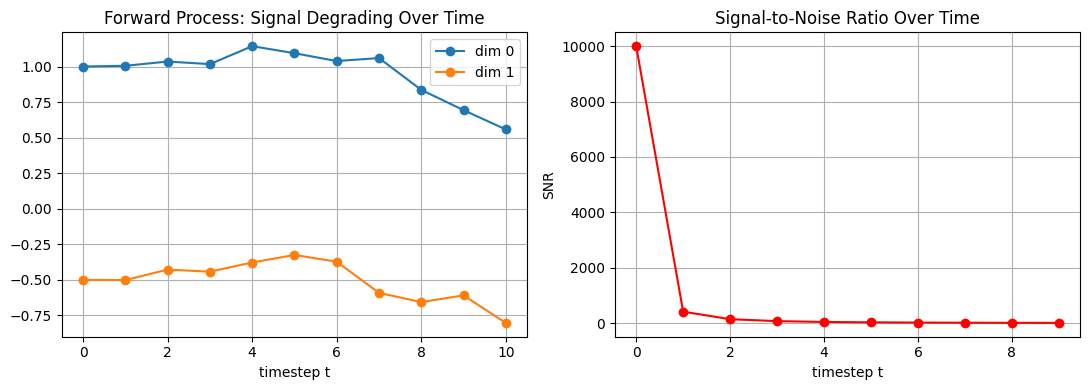

In [6]:
np.random.seed(42)

T = 10
beta = np.linspace(0.0001, 0.02, T)
alpha = 1 - beta
alpha_bar = np.cumprod(alpha)

x_clean = np.array([1.0, -0.5])

# Forward: add noise step by step
forward_trajectory = [x_clean.copy()]
x = x_clean.copy()
for i in range(T):
    eps = np.random.randn(*x.shape)
    x = np.sqrt(alpha[i]) * x + np.sqrt(beta[i]) * eps
    forward_trajectory.append(x.copy())

forward_trajectory = np.array(forward_trajectory)
snr = alpha_bar / (1 - alpha_bar)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(forward_trajectory[:, 0], label='dim 0', marker='o')
axes[0].plot(forward_trajectory[:, 1], label='dim 1', marker='o')
axes[0].set_title("Forward Process: Signal Degrading Over Time")
axes[0].set_xlabel("timestep t"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(snr, marker='o', color='red')
axes[1].set_title("Signal-to-Noise Ratio Over Time")
axes[1].set_xlabel("timestep t"); axes[1].set_ylabel("SNR"); axes[1].grid(True)

plt.tight_layout()
plt.show()